In [ ]:
#step 1 - Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#step 2 - set dataset path
dataset_path = "/content/drive/MyDrive/Dataset" # PLEASE REPLACE 'YourDatasetName' with the actual name of your dataset folder

In [ ]:
#step 3 - import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
#step 4 - prepare image dataset
# Ensure ImageDataGenerator is imported (step 3) before running this cell.
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
#step 5 - Load Training Dataset
train_dataset = datagen.flow_from_directory(
    dataset_path,
    target_size=(51,51),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 41 images belonging to 5 classes.


In [ ]:
#step 6 - Load Validation Dataset
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(51,51),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 10 images belonging to 5 classes.


In [ ]:
#step 7 - build simple CNN
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(51,51,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(train_dataset.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#step 8 - compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
#step 9 - model fitting
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_data
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.2439 - loss: 1.9716 - val_accuracy: 0.2000 - val_loss: 2.0536
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 5s/step - accuracy: 0.1951 - loss: 1.8607 - val_accuracy: 0.4000 - val_loss: 1.7513
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3659 - loss: 1.6982 - val_accuracy: 0.4000 - val_loss: 1.5357
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step - accuracy: 0.3902 - loss: 1.4575 - val_accuracy: 0.4000 - val_loss: 1.4579
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 5s/step - accuracy: 0.6098 - loss: 1.3484 - val_accuracy: 0.6000 - val_loss: 1.3806
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step - accuracy: 1.0000 - loss: 1.2452 - val_accuracy: 0.8000 - val_loss: 1.3008
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.9512 - loss: 1.1825 - val_accuracy: 0.7000 - val_loss: 1.2112
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9512 - loss: 1.0554 - val_accuracy: 0.6000 - val_loss: 1.1479
Epoch 9/10
2/2 ━

In [ ]:
#step 10 evaluate model
loss, accuracy = model.evaluate(validation_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step - accuracy: 0.9000 - loss: 0.8886
Validation Loss: 0.8886324167251587
Validation Accuracy: 0.8999999761581421


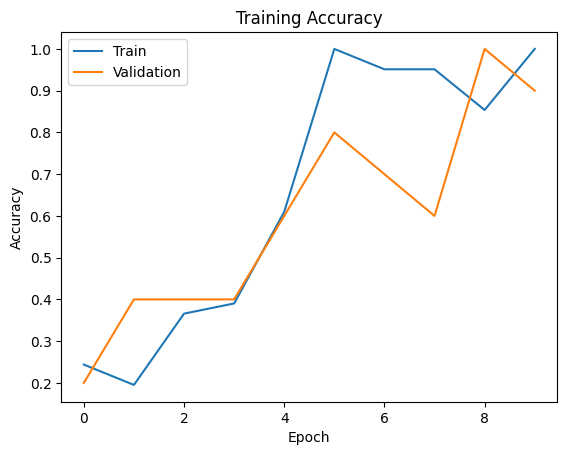

In [ ]:
#step 11 - plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
#step 12 - save model

model.save('my_model.h5')